### Chain Using LangGraph
In this section we will build a simple chain using Langgraph that uses the following important concepts

- How to use chat messages as our graph state
- How to use chat models in graph nodes
- How to bind tools to our LLM in chat models
- How to execute the tools call in our graph nodes 

In [1]:
import os
from dotenv import load_dotenv

from typing_extensions import TypedDict

from langchain_core.messages import HumanMessage, AIMessage, AnyMessage
from langgraph.graph.message import add_messages

from pprint import pprint

from langchain_groq import ChatGroq

Messages in a conversation can take on different roles.  
LangChain defines four main types: **HumanMessage** (user input), **AIMessage** (model output), **SystemMessage** (instructions for the model), and **ToolMessage** (responses from tools).  

Each message includes three essential components:  
- **content** – the actual text or payload  
- **name** – the author or source  
- **response_metadata** – optional metadata, often added by providers for AI messages  

In [2]:
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')

In [3]:
messages = [
    AIMessage(content=f'Hi, please tell me how can I help you?', name='LLM Model')
]

messages.append(HumanMessage(content='I want to learn programming', name='Saheed'))
messages.append(AIMessage(content=f'Please which language you want to learn?', name='LLM Model'))
messages.append(HumanMessage(content=f'I want to learn python and GoLang programming language', name='Saheed'))

for msg in messages:
    msg.pretty_print()

================================== Ai Message ==================================
Name: LLM Model

Hi, please tell me how can I help you?
================================ Human Message =================================
Name: Saheed

I want to learn programming
================================== Ai Message ==================================
Name: LLM Model

Please which language you want to learn?
================================ Human Message =================================
Name: Saheed

I want to learn python and GoLang programming language


### Chat Models

Using sequence of message as input with the chatmodels using LLM's and OPENAI.

In [4]:
llm = ChatGroq(model='llama-3.1-8b-instant')
response = llm.invoke(messages)
response

AIMessage(content="Both Python and GoLang are popular and versatile languages with many applications. Here's a brief overview to get you started:\n\n**Python:**\n\n1. **Why learn Python?**\n\t* Easy to learn and use\n\t* Versatile: web development, data analysis, machine learning, automation, and more\n\t* Large community and resources\n2. **What can you do with Python?**\n\t* Web development with frameworks like Django and Flask\n\t* Data analysis and visualization with libraries like Pandas and Matplotlib\n\t* Machine learning and AI with libraries like TensorFlow and Scikit-learn\n\t* Automation and scripting\n3. **Resources to learn Python:**\n\t* Codecademy's Python course\n\t* Python.org (official documentation)\n\t* Automate the Boring Stuff with Python (book)\n\t* Python Crash Course (book)\n\n**GoLang:**\n\n1. **Why learn GoLang?**\n\t* Fast and concurrent programming\n\t* Simple and intuitive syntax\n\t* Growing community and ecosystem\n2. **What can you do with GoLang?**\n\t

In [5]:
response.response_metadata

{'token_usage': {'completion_tokens': 553,
  'prompt_tokens': 84,
  'total_tokens': 637,
  'completion_time': 0.711066737,
  'prompt_time': 0.004757537,
  'queue_time': 0.005106544,
  'total_time': 0.715824274},
 'model_name': 'llama-3.1-8b-instant',
 'system_fingerprint': 'fp_03e8423237',
 'service_tier': 'on_demand',
 'finish_reason': 'stop',
 'logprobs': None}

Tools

In [6]:
def add(a:int, b:int)-> int:
    '''
    Add integers a and 
    a: first integer
    b: second integer
    Return a + b
    '''
    return a + b
    

In [7]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000002259D25FC50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002259D398890>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [8]:
# Binding tools with LLM
binding_llm_with_tools = llm.bind_tools([add])
response = binding_llm_with_tools.invoke([
    HumanMessage(content='What is 2 plus 5?', name='Saheed')
])

response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sfj3xgt82', 'function': {'arguments': '{"a":2,"b":5}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 252, 'total_tokens': 272, 'completion_time': 0.025836748, 'prompt_time': 0.013983777, 'queue_time': 0.038702071, 'total_time': 0.039820525}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019d2611-f369-7351-90b4-80bb2cace290-0', tool_calls=[{'name': 'add', 'args': {'a': 2, 'b': 5}, 'id': 'sfj3xgt82', 'type': 'tool_call'}], usage_metadata={'input_tokens': 252, 'output_tokens': 20, 'total_tokens': 272})

In [9]:
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 5},
  'id': 'sfj3xgt82',
  'type': 'tool_call'}]

Using messages as state

In [10]:
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Reducers with add_messages

In [11]:
initial_messages = [
    AIMessage(content=f'Hi, please tell me how can I help you?', name='LLM Model')
]

initial_messages.append(HumanMessage(content='I want to learn programming', name='Saheed'))
initial_messages

[AIMessage(content='Hi, please tell me how can I help you?', additional_kwargs={}, response_metadata={}, name='LLM Model'),
 HumanMessage(content='I want to learn programming', additional_kwargs={}, response_metadata={}, name='Saheed')]

In [12]:
ai_messages = AIMessage(content=f'Please which language you want to learn?', name='LLM Model')
#messages.append(HumanMessage(content=f'I want to learn python and GoLang programming language', name='Saheed'))
ai_messages

AIMessage(content='Please which language you want to learn?', additional_kwargs={}, response_metadata={}, name='LLM Model')

In [13]:
#Reducers: to append and not overridw
add_messages(initial_messages, ai_messages)

[AIMessage(content='Hi, please tell me how can I help you?', additional_kwargs={}, response_metadata={}, name='LLM Model', id='263c8d39-6cbc-4040-9145-a00432a205ff'),
 HumanMessage(content='I want to learn programming', additional_kwargs={}, response_metadata={}, name='Saheed', id='007721ca-d23c-46cb-9158-706a4cd91231'),
 AIMessage(content='Please which language you want to learn?', additional_kwargs={}, response_metadata={}, name='LLM Model', id='ea72f6a4-a904-44c1-bc8b-479aaea0b398')]

In [14]:
#Create chatbot function
def  llm_tool(state: State):
    
    return {
        'messages': [binding_llm_with_tools.invoke(state['messages'])]
    }

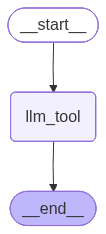

In [16]:
builder = StateGraph(State)

builder.add_node('llm_tool', llm_tool)
builder.add_edge(START, 'llm_tool')
builder.add_edge('llm_tool', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
#Invoke
messages = graph.invoke({
    'messages': 'What is 3 + 7'
})

messages

{'messages': [HumanMessage(content='What is 3 + 7', additional_kwargs={}, response_metadata={}, id='d1d057ef-d7f4-446e-b5d1-6868770d9408'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'r2pvcdwgk', 'function': {'arguments': '{"a":3,"b":7}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 251, 'total_tokens': 269, 'completion_time': 0.028302874, 'prompt_time': 0.015502192, 'queue_time': 0.005235445, 'total_time': 0.043805066}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_8639719ff2', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019d266a-6102-72a0-a0d1-c3be0c684d63-0', tool_calls=[{'name': 'add', 'args': {'a': 3, 'b': 7}, 'id': 'r2pvcdwgk', 'type': 'tool_call'}], usage_metadata={'input_tokens': 251, 'output_tokens': 18, 'total_tokens': 269})]}

In [18]:
for msg in messages['messages']:
    msg.pretty_print()
    

================================ Human Message =================================

What is 3 + 7
================================== Ai Message ==================================
Tool Calls:
  add (r2pvcdwgk)
 Call ID: r2pvcdwgk
  Args:
    a: 3
    b: 7


Integrating Tools with Tools Node

In [19]:
from langgraph.prebuilt import ToolNode, tools_condition

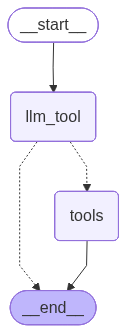

In [21]:
# Create tool
tools = [add]

builder = StateGraph(State)

#Add node
builder.add_node('llm_tool', llm_tool)
builder.add_node('tools', ToolNode(tools))

#Add Edge
builder.add_edge(START, 'llm_tool')
builder.add_conditional_edges('llm_tool', tools_condition)

builder.add_edge('tools', END)

graph_builder = builder.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [24]:
#Invoke
messages = graph_builder.invoke({
    'messages': 'What is 3 + 7'
})

messages

for msg in messages['messages']:
    msg.pretty_print()
    

================================ Human Message =================================

What is 3 + 7
================================== Ai Message ==================================
Tool Calls:
  add (nn6bf827b)
 Call ID: nn6bf827b
  Args:
    a: 3
    b: 7
================================= Tool Message =================================
Name: add

10


In [26]:
#Invoke
messages = graph_builder.invoke({
    'messages': 'What are the things to land my first job at upwork for machine learning role since it is my first time and i have used all free credit card'
})

messages

for msg in messages['messages']:
    msg.pretty_print()
    

================================ Human Message =================================

What are the things to land my first job at upwork for machine learning role since it is my first time and i have used all free credit card
================================== Ai Message ==================================

It can be challenging to land your first job on Upwork, especially with a free credit card and no prior experience. However, here are some tips that may help:

1. **Create a professional profile**: Make sure your Upwork profile is complete, up-to-date, and professional. This includes a clear and concise headline, a professional profile picture, and a detailed description of your skills and experience.

2. **Build a strong portfolio**: Create a portfolio that showcases your work and skills. This can include projects you've worked on in the past, certifications you've earned, or even personal projects you've completed.

3. **Develop a strong proposal template**: A well-written proposal can